In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

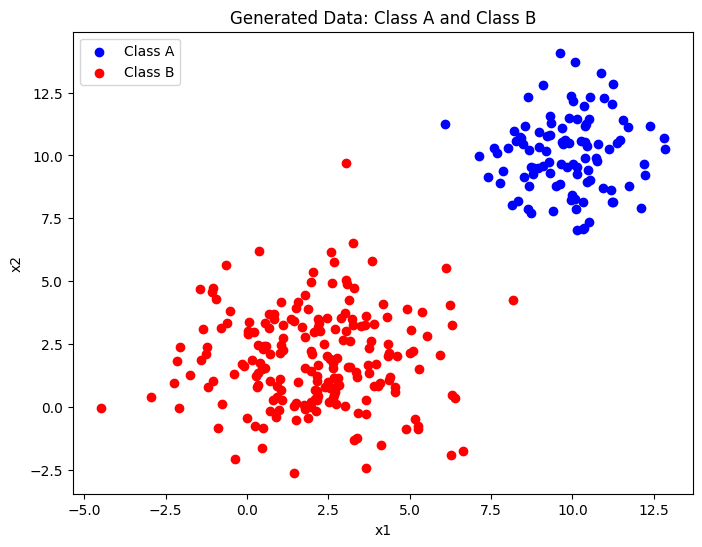

In [67]:
np.random.seed(42)
class_A = np.random.normal(loc=(10, 10), scale=1.5, size=(100, 2))
labels_A = np.ones(class_A.shape[0])

class_B = np.random.normal(loc=(2, 2), scale=2, size=(200, 2))
labels_B = np.zeros(class_B.shape[0])

X = np.vstack((class_A, class_B))
y = np.hstack((labels_A, labels_B))

plt.figure(figsize=(8, 6))
plt.scatter(class_A[:, 0], class_A[:, 1], color='blue', label='Class A')
plt.scatter(class_B[:, 0], class_B[:, 1], color='red', label='Class B')
plt.title('Generated Data: Class A and Class B')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [68]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
            
        y_predicted_class = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_class)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
model = LogisticRegression(learning_rate=0.3, epochs=100000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [71]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


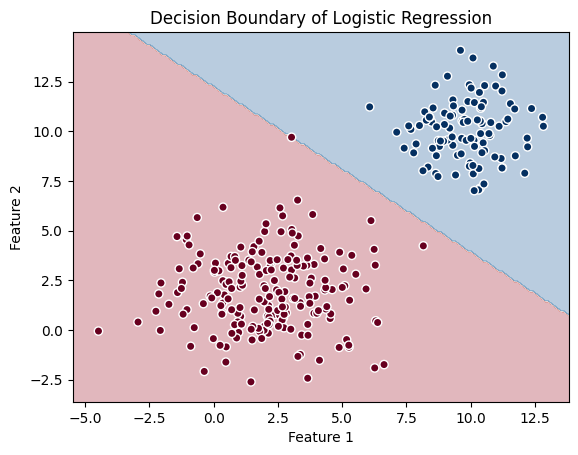

In [72]:
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.1), np.arange(x1_min, x1_max, 0.1))
grid = np.c_[xx0.ravel(), xx1.ravel()]
probs = model.predict(grid).reshape(xx0.shape)

plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='RdBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='white', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title("Decision Boundary of Logistic Regression")
plt.show()